In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

# Suppress TF info logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Config — all our key settings in one place
DATASET_PATH = r"C:\Users\User\plantvillage\plantvillage dataset\color"
IMG_SIZE     = (128, 128)   # resize from 256x256 to save memory
BATCH_SIZE   = 32
SEED         = 42

print("TensorFlow version:", tf.__version__)
print("All imports successful ✓")

TensorFlow version: 2.21.0
All imports successful ✓


In [3]:
# Training set (80%)
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Validation set (10%) and Test set (10%)
# We split the remaining 20% in half
val_test_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Split val_test_ds into val and test
val_batches = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds  = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

class_names = train_ds.class_names

print(f"Classes: {len(class_names)}")
print(f"Train batches:      {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches:       {tf.data.experimental.cardinality(test_ds)}")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Classes: 38
Train batches:      1358
Validation batches: 170
Test batches:       170


In [4]:
# Rescale pixel values from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_norm = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_norm   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_norm  = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Verify pixel range
for images, labels in train_ds_norm.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Pixel min: {images.numpy().min():.3f}")
    print(f"Pixel max: {images.numpy().max():.3f}")
    print("Normalization confirmed ✓" if images.numpy().max() <= 1.0 else "⚠ Check normalization")

Image batch shape: (32, 128, 128, 3)
Pixel min: 0.000
Pixel max: 0.994
Normalization confirmed ✓


In [5]:
# Augmentation layers — applied only during training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

print("Augmentation pipeline:")
data_augmentation.summary()

Augmentation pipeline:


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_brightness (RandomBrightness) │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

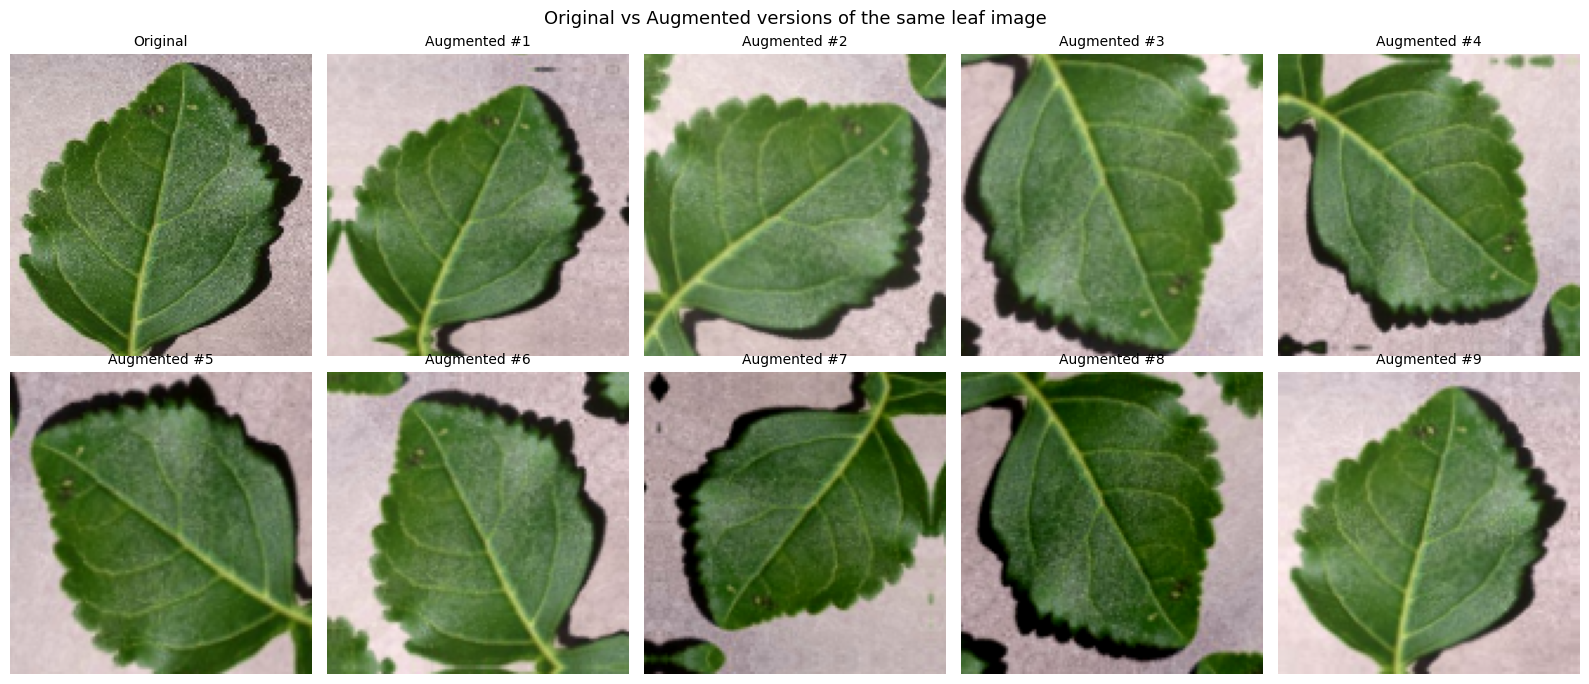

In [6]:
# Grab one batch of images
for images, labels in train_ds.take(1):
    sample_image = images[0:1]  # shape: (1, 128, 128, 3)
    break

# Normalize for display
sample_norm = sample_image / 255.0

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes[0, 0].imshow(sample_norm[0])
axes[0, 0].set_title("Original", fontsize=10)
axes[0, 0].axis('off')

# Show 9 augmented versions
for i, ax in enumerate(axes.flat):
    if i == 0:
        continue
    augmented = data_augmentation(sample_image, training=True)
    aug_norm = augmented[0].numpy() / 255.0
    aug_norm = np.clip(aug_norm, 0, 1)
    ax.imshow(aug_norm)
    ax.set_title(f"Augmented #{i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Original vs Augmented versions of the same leaf image", fontsize=13)
plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cache and prefetch for fast training
AUTOTUNE = tf.data.AUTOTUNE

train_ds_final = (
    train_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .map(lambda x, y: (data_augmentation(x, training=True), y))
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds_final = (
    val_ds_norm
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds_final = (
    test_ds_norm
    .cache()
    .prefetch(AUTOTUNE)
)

print("Final pipeline ready ✓")
print(f"Train:      augmented + normalized + cached")
print(f"Validation: normalized + cached")
print(f"Test:       normalized + cached")

# Save class names for later tasks
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print(f"\nSaved class_names.json ({len(class_names)} classes) ✓")

Final pipeline ready ✓
Train:      augmented + normalized + cached
Validation: normalized + cached
Test:       normalized + cached

Saved class_names.json (38 classes) ✓
